# 03 - 建筑基底生成

**目标**：在用地分区内生成模拟的建筑 footprint（基底轮廓）。

**算法**：
1. 对每个用地 parcel，计算目标建筑数量（基于覆盖率）
2. 在 parcel 内网格布点，添加随机偏移
3. 每个建筑生成矩形 footprint，裁剪到 parcel 边界内
4. 根据 `land_use_code` 分配 `building_type`

**学习要点**：
- 空间约束下的几何生成
- 建筑类型与用地类型的对应关系
- 覆盖率控制

In [1]:
import sys
sys.path.insert(0, '..')

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from shapely.ops import unary_union, transform
from shapely.geometry import Polygon, box
import pyproj

from src.projection import transform_geometry, CRS_4326, CRS_4548
from src.generation import (
    subdivide_boundary,
    assign_land_use,
    generate_buildings_in_parcel,
    LAND_USE_COLORS,
    LAND_USE_LABELS,
)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Re-generate land use parcels (same as notebook 02)
gdf_all = gpd.read_file('../data/haidian-boundary.geojson')
site = gdf_all[gdf_all['id'] == 'PROV-SITE-001'].iloc[0]
boundary_4548 = transform_geometry(site.geometry, CRS_4326, CRS_4548)
cells = subdivide_boundary(boundary_4548, n_rows=20, n_cols=15)
land_use_gdf = assign_land_use(cells, random_seed=42)

print(f'Land use parcels: {len(land_use_gdf)}')

Land use parcels: 278


## Step 1: 为每个用地 parcel 生成建筑

对每个 parcel 调用 `generate_buildings_in_parcel`。不同用地类型使用不同的覆盖率（建筑密度）和建筑类型。

In [3]:
# Coverage ratios by land use type
# (GB 50137-2011: education is A3, part of A 公共管理与公共服务用地)
COVERAGE_BY_LANDUSE = {
    'R': 0.30,   # Residential — 30% building coverage
    'A': 0.25,   # Administration + education — 25%
    'B': 0.35,   # Commercial — 35%
    'G': 0.05,   # Green space — 5% (pavilions only)
    'S': 0.10,   # Transportation — 10%
}

# Building types by land use
BUILDING_TYPES = {
    'R': ['residential_tower', 'residential_slab'],
    'A': ['office_tower', 'office_podium', 'school_building', 'sports_hall'],
    'B': ['commercial_block', 'mixed_use_tower'],
    'G': ['park_pavilion'],
    'S': ['transit_station'],
}

# Building dimensions by type (width, depth in metres)
BUILDING_DIMS = {
    'residential_tower': (18, 18),     # Tower
    'residential_slab': (30, 14),      # Slab block
    'office_tower': (22, 22),          # Office tower
    'office_podium': (40, 20),         # Podium
    'commercial_block': (25, 25),      # Commercial
    'mixed_use_tower': (20, 20),       # Mixed use
    'park_pavilion': (8, 8),           # Small pavilion
    'transit_station': (15, 10),       # Station
    'school_building': (35, 15),       # School
    'sports_hall': (40, 25),           # Sports hall
}

In [4]:
all_buildings = []
parcel_stats = []

for idx, row in land_use_gdf.iterrows():
    parcel = row.geometry
    land_use = row['land_use_code']

    coverage = COVERAGE_BY_LANDUSE.get(land_use, 0.25)
    bldg_types = BUILDING_TYPES.get(land_use, ['generic'])

    # Use first building type to determine dimensions
    primary_type = bldg_types[0]
    dims = BUILDING_DIMS.get(primary_type, (15, 12))

    bldg_gdf = generate_buildings_in_parcel(
        parcel,
        coverage_ratio=coverage,
        bldg_types=bldg_types,
        bldg_width=dims[0],
        bldg_depth=dims[1],
        random_seed=idx,
    )

    if len(bldg_gdf) > 0:
        bldg_gdf['parcel_id'] = idx
        bldg_gdf['land_use_code'] = land_use
        all_buildings.append(bldg_gdf)
        parcel_stats.append({
            'parcel_id': idx,
            'land_use_code': land_use,
            'parcel_area': parcel.area,
            'building_count': len(bldg_gdf),
            'building_area': bldg_gdf.geometry.area.sum(),
        })

buildings_gdf = gpd.GeoDataFrame(
    pd.concat(all_buildings, ignore_index=True), crs='EPSG:4548'
)

stats_gdf = gpd.GeoDataFrame(parcel_stats)

print(f'Total buildings generated: {len(buildings_gdf)}')
print(f'Building types: {buildings_gdf["building_type"].unique().tolist()}')

Total buildings generated: 8404
Building types: ['mixed_use_tower', 'commercial_block', 'residential_tower', 'residential_slab', 'park_pavilion', 'transit_station', 'office_podium', 'sports_hall', 'school_building', 'office_tower']


In [5]:
# Summary statistics by land use
print('=== Building Generation Summary ===')
print()
for lu in sorted(stats_gdf['land_use_code'].unique()):
    subset = stats_gdf[stats_gdf['land_use_code'] == lu]
    total_parcel = subset['parcel_area'].sum()
    total_bldg = subset['building_area'].sum()
    count = subset['building_count'].sum()
    ratio = total_bldg / total_parcel * 100 if total_parcel > 0 else 0
    label = LAND_USE_LABELS.get(lu, lu)
    print(f'{label:30s} {count:4d} buildings, coverage: {ratio:5.1f}%')

=== Building Generation Summary ===

A 公共管理与公共服务用地                   853 buildings, coverage:  24.8%
B 商业服务业设施用地                     814 buildings, coverage:  33.1%
G 绿地与广场用地                      1309 buildings, coverage:   4.9%
R 居住用地                         4051 buildings, coverage:  29.6%
S 道路与交通设施用地                    1377 buildings, coverage:   9.7%


## Step 2: 验证 — 所有建筑在对应 parcel 内

In [6]:
# Verify: each building is within its parcel
# (area-based: a building is a violator only if it pokes outside by more
#  than the floating-point tolerance — clipped edges can differ in the last
#  bit, cf. src.topology.AREA_TOLERANCE_SQM)
from src.topology import AREA_TOLERANCE_SQM

violations = 0
for idx, bldg_row in buildings_gdf.iterrows():
    parcel_id = bldg_row['parcel_id']
    parcel_geom = land_use_gdf.iloc[parcel_id].geometry
    if bldg_row.geometry.difference(parcel_geom).area > AREA_TOLERANCE_SQM:
        violations += 1

print(f'=== Containment Check ===')
print(f'Total buildings: {len(buildings_gdf)}')
print(f'Buildings materially outside parcel (> {AREA_TOLERANCE_SQM} m²): {violations}')
print(f'All inside: {violations == 0}')

if violations > 0:
    print(f'  ⚠ {violations} buildings are outside their parent parcel')
else:
    print('  ✓ All buildings within their parent parcels')

=== Containment Check ===
Total buildings: 8404
Buildings materially outside parcel (> 0.0001 m²): 0
All inside: True
  ✓ All buildings within their parent parcels


In [7]:
# Verify: all buildings within overall boundary (area-based, see above)
from src.topology import AREA_TOLERANCE_SQM

outside_boundary = 0
for idx, bldg_row in buildings_gdf.iterrows():
    if bldg_row.geometry.difference(boundary_4548).area > AREA_TOLERANCE_SQM:
        outside_boundary += 1

print(f'Buildings materially outside overall boundary (> {AREA_TOLERANCE_SQM} m²): {outside_boundary}')
if outside_boundary == 0:
    print('  ✓ All buildings within overall boundary')
else:
    print(f'  ⚠ {outside_boundary} buildings outside boundary')

Buildings materially outside overall boundary (> 0.0001 m²): 0
  ✓ All buildings within overall boundary


## Step 3: 可视化

/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_90506/2395657698.py:39: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_90506/2395657698.py:39: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_90506/2395657698.py:39: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_90506/2395657698.py:39: UserWarning: Glyph 31569 (\N{CJK UNIFIED IDEOGRAPH-7B51}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/hgj2rww17nb_x9q7pdkxh49r0000gn/T/ipykernel_90506/2395657698.py:39: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/hgj2

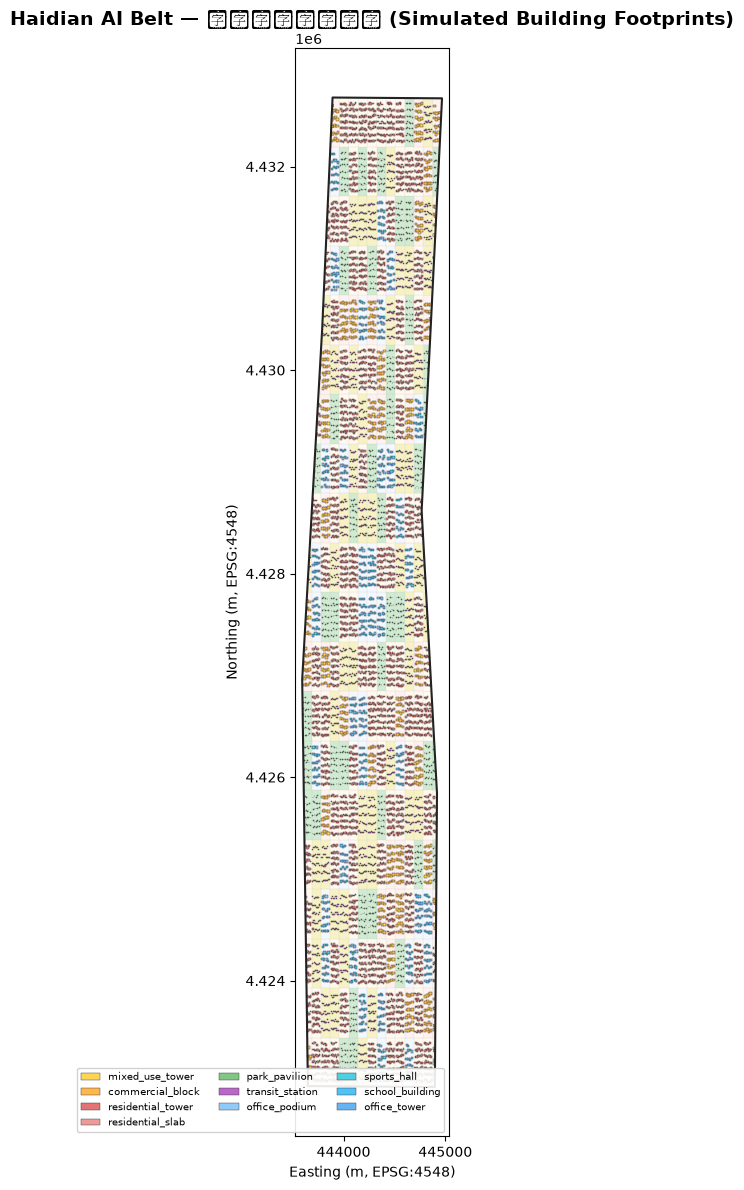

In [8]:
# Color by building type
BUILDING_COLORS = {
    'residential_tower': '#E57373',
    'residential_slab': '#EF9A9A',
    'office_tower': '#64B5F6',
    'office_podium': '#90CAF9',
    'commercial_block': '#FFB74D',
    'mixed_use_tower': '#FFD54F',
    'park_pavilion': '#81C784',
    'transit_station': '#BA68C8',
    'school_building': '#4FC3F7',
    'sports_hall': '#4DD0E1',
}

fig, ax = plt.subplots(figsize=(16, 12))

# Plot land use parcels as background
for code in sorted(land_use_gdf['land_use_code'].unique()):
    subset = land_use_gdf[land_use_gdf['land_use_code'] == code]
    color = LAND_USE_COLORS.get(code, '#CCCCCC')
    subset.plot(ax=ax, color=color, edgecolor='#CCCCCC', linewidth=0.2, alpha=0.5)

# Plot buildings on top
for btype in buildings_gdf['building_type'].unique():
    subset = buildings_gdf[buildings_gdf['building_type'] == btype]
    color = BUILDING_COLORS.get(btype, '#888888')
    subset.plot(ax=ax, color=color, edgecolor='#333333', linewidth=0.3, label=btype)

# Boundary
gpd.GeoSeries([boundary_4548]).plot(
    ax=ax, facecolor='none', edgecolor='#222222', linewidth=1.5
)

ax.set_title('Haidian AI Belt — 模拟建筑基底分布 (Simulated Building Footprints)', fontsize=14, fontweight='bold')
ax.set_xlabel('Easting (m, EPSG:4548)')
ax.set_ylabel('Northing (m, EPSG:4548)')
ax.legend(loc='lower right', fontsize=7, framealpha=0.9, ncol=3)

plt.tight_layout()
plt.savefig('../outputs/building_footprints_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## 总结

- 成功在用地分区内生成了建筑基底 footprint
- 所有建筑通过了包含性验证（在 parcel 内，在 boundary 内）
- 不同用地类型有不同的建筑类型和覆盖率
- 下一步：生成道路网络